
# SisFall Training Pipeline

- TensorFlow Lite Float32 export
- TensorFlow Lite INT8 export
- Edge-device deployment artefacts
- Confusion matrix and performance reports

Recommended dataset layout:

```text
SisFall_dataset/
├── SA01 ... SA23
├── SE01 ... SE15
└── Readme.txt
```


In [ ]:
!pip install tensorflow-model-optimization
!pip install ai-edge-litert

import os
import math
import json
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
)

from sklearn.preprocessing import StandardScaler
import joblib

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import callbacks
from tensorflow.keras import models
import tensorflow_model_optimization as tfmot

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [ ]:
%matplotlib inline

# Mount Google Drive and Setup Paths

from google.colab import drive

google_drive_path = "/content/drive"

# Mount Google Drive
drive.mount(google_drive_path, force_remount=True)

# Project custom drive path
my_path = "AG/FH/study/AI_IoT/node/milestone2"

# Declare project home directory
project_path = f"{google_drive_path}/MyDrive/{my_path}"
os.makedirs(project_path, exist_ok=True)

SISFALL_ROOT = f"{project_path}/SisFall"
os.makedirs(SISFALL_ROOT, exist_ok=True)


MODEL_DIR = f"{SISFALL_ROOT}/exports"
os.makedirs(MODEL_DIR, exist_ok=True)



Mounted at /content/drive


In [ ]:

# Configuration

DATASET_ROOT = f"{project_path}/SisFall_dataset"

WINDOW_SIZE = 200
STRIDE = 100

TEST_SUBJECT_FRACTION = 0.20


FALL_PREFIX = "F"
ADL_PREFIX = "D"


In [ ]:

# SisFall Loader

def load_sisfall_file(filepath):

    rows = []

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            values = re.split(r"[,;\s]+", line)

            try:
                values = [float(v) for v in values if v != ""]
            except:
                continue

            rows.append(values)

    if len(rows) == 0:
        return None

    arr = np.asarray(rows, dtype=np.float32)

    return arr


def activity_to_label(activity):

    if activity.startswith(FALL_PREFIX):
        return 1

    return 0


In [ ]:

# Dataset Parsing

samples = []
labels = []
subjects = []

root = Path(DATASET_ROOT)

subject_dirs = sorted(
    [d for d in root.iterdir() if d.is_dir()]
)

for subject_dir in subject_dirs:

    subject = subject_dir.name

    txt_files = sorted(subject_dir.glob("*.txt"))

    for txt_file in txt_files:

        activity = txt_file.stem.split("_")[0]

        label = activity_to_label(activity)

        signal = load_sisfall_file(txt_file)

        if signal is None:
            continue

        for start in range(
            0,
            len(signal) - WINDOW_SIZE,
            STRIDE,
        ):

            window = signal[start:start + WINDOW_SIZE]

            samples.append(window)
            labels.append(label)
            subjects.append(subject)

X = np.asarray(samples, dtype=np.float32)
y = np.asarray(labels, dtype=np.int32)
groups = np.asarray(subjects)

print("Windows:", len(X))
print("Shape:", X.shape)
print("Falls:", np.sum(y == 1))
print("ADL:", np.sum(y == 0))
print("Subjects:", len(np.unique(groups)))


Windows: 149632
Shape: (149632, 200, 9)
Falls: 50345
ADL: 99287
Subjects: 38


In [ ]:

# Subject-Independent Split

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SUBJECT_FRACTION,
    random_state=SEED,
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

train_subjects = np.unique(groups[train_idx])
test_subjects = np.unique(groups[test_idx])

print("Train subjects:", train_subjects)
print("Test subjects:", test_subjects)


Train subjects: ['SA01' 'SA02' 'SA03' 'SA04' 'SA06' 'SA08' 'SA09' 'SA10' 'SA11' 'SA12'
 'SA13' 'SA15' 'SA16' 'SA17' 'SA18' 'SA19' 'SA20' 'SA21' 'SA22' 'SA23'
 'SE01' 'SE02' 'SE03' 'SE06' 'SE07' 'SE09' 'SE10' 'SE12' 'SE13' 'SE15']
Test subjects: ['SA05' 'SA07' 'SA14' 'SE04' 'SE05' 'SE08' 'SE11' 'SE14']


In [ ]:

# Channel Normalisation

n_channels = X_train.shape[-1]

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_channels)
X_test_2d = X_test.reshape(-1, n_channels)

X_train_2d = scaler.fit_transform(X_train_2d)
X_test_2d = scaler.transform(X_test_2d)

X_train = X_train_2d.reshape(X_train.shape)
X_test = X_test_2d.reshape(X_test.shape)

joblib.dump(
    scaler,
    f"{MODEL_DIR}/sisfall_scaler.pkl"
)


['/content/drive/MyDrive/AG/FH/study/AI_IoT/node/milestone2/SisFall/exports/sisfall_scaler.pkl']

In [ ]:

# CNN Model

base_model = models.Sequential([

    layers.Input(
        shape=(
            WINDOW_SIZE,
            X_train.shape[-1]
        )
    ),

    layers.Conv1D(
        32,
        5,
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(
        64,
        5,
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(
        128,
        3,
        activation="relu",
        padding="same"
    ),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        128,
        activation="relu"
    ),
    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

base_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

base_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,017 (211.00 KB)

 Trainable params: 53,569 (209.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:

# Training

checkpoint = callbacks.ModelCheckpoint(
    f"{MODEL_DIR}/best_sisfall_cnn.keras",
    save_best_only=True,
    monitor="val_auc",
    mode="max"
)

early_stop = callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor="val_auc",
    mode="max"
)

history = base_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    callbacks=[checkpoint, early_stop],
    verbose=1
)


Epoch 1/100
773/773 ━━━━━━━━━━━━━━━━━━━━ 98s 122ms/step - accuracy: 0.8159 - auc: 0.8879 - loss: 0.4069 - val_accuracy: 0.8109 - val_auc: 0.8567 - val_loss: 0.4676
Epoch 2/100
773/773 ━━━━━━━━━━━━━━━━━━━━ 150s 133ms/step - accuracy: 0.8555 - auc: 0.9285 - loss: 0.3318 - val_accuracy: 0.7744 - val_auc: 0.8581 - val_loss: 0.5248
Epoch 3/100
773/773 ━━━━━━━━━━━━━━━━━━━━ 138s 127ms/step - accuracy: 0.8731 - auc: 0.9440 - loss: 0.2952 - val_accuracy: 0.7858 - val_auc: 0.8458 - val_loss: 0.5061
Epoch 4/100
773/773 ━━━━━━━━━━━━━━━━━━━━ 136s 120ms/step - accuracy: 0.8833 - auc: 0.9523 - loss: 0.2730 - val_accuracy: 0.7471 - val_auc: 0.8694 - val_loss: 0.5928
Epoch 5/100
773/773 ━━━━━━━━━━━━━━━━━━━━ 94s 122ms/step - accuracy: 0.8908 - auc: 0.9582 - loss: 0.2562 - val_accuracy: 0.7329 - val_auc: 0.8659 - val_loss: 0.6657
Epoch 6/100
773/773 ━━━━━━━━━━━━━━━━━━━━ 141s 121ms/step - accuracy: 0.8973 - auc: 0.9630 - loss: 0.2414 - val_accuracy: 0.7233 - val_auc: 0.8736 - val_loss: 0.6630
Epoch 7/100


In [ ]:

# Evaluation

probs = base_model.predict(X_test).ravel()
preds = (probs >= 0.5).astype(int)

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("Accuracy:", acc)
print("F1:", f1)

print(
    classification_report(
        y_test,
        preds,
        target_names=[
            "ADL",
            "FALL"
        ]
    )
)


813/813 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
Accuracy: 0.7422581265628005
F1: 0.6117292535929532
              precision    recall  f1-score   support

         ADL       0.93      0.71      0.81     19694
        FALL       0.48      0.84      0.61      6301

    accuracy                           0.74     25995
   macro avg       0.71      0.77      0.71     25995
weighted avg       0.82      0.74      0.76     25995



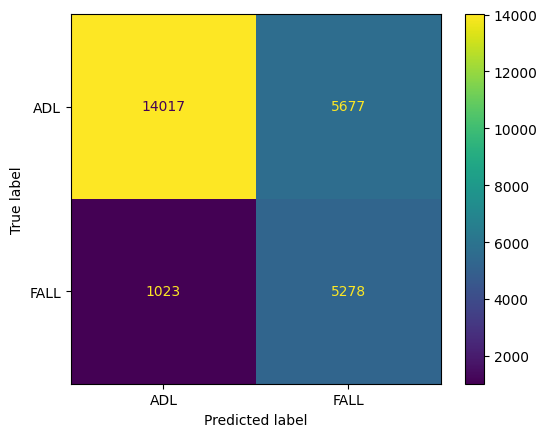

In [ ]:

# Confusion Matrix

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["ADL","FALL"]
)

disp.plot()
plt.show()


In [ ]:

# Save Keras Model

base_model.save(
    f"{MODEL_DIR}/sisfall_cnn.keras"
)


In [ ]:

# Float32 TFLite Export

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)

tflite_model = converter.convert()

with open(
    f"{MODEL_DIR}/sisfall_float32.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("Float32 export complete")


Saved artifact at '/tmp/tmpuiitnfup'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135342028143888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914701904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914703248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135342028143504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914705936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914706128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704016: Te

In [ ]:

# INT8 Quantisation

def representative_dataset():

    for i in range(
        min(
            1000,
            len(X_train)
        )
    ):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(base_model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quant_model = converter.convert()

with open(
    f"{MODEL_DIR}/sisfall_int8.tflite",
    "wb"
) as f:
    f.write(quant_model)

print("INT8 export complete")


Saved artifact at '/tmp/tmpw9d2vz08'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 9), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135342028143888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914701904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914703248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135342028143504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914705936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914706128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135341914704016: Te

In [ ]:
# QAT — Quantisation-Aware Training

qat_model = tfmot.quantization.keras.quantize_model(base_model)

qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

print("Fine-tuning model with QAT...")
qat_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,           # short fine-tune; base model is already trained
    batch_size=128,
    verbose=1,
)

# QAT → INT8 TFLite Export

def representative_dataset_qat():
    for i in range(min(1000, len(X_train))):
        yield [X_train[i : i + 1].astype(np.float32)]

converter_qat = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter_qat.optimizations = [tf.lite.Optimize.DEFAULT]
converter_qat.representative_dataset = representative_dataset_qat
converter_qat.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_qat.inference_input_type = tf.int8
converter_qat.inference_output_type = tf.int8

tflite_qat_model = converter_qat.convert()

qat_model_path = f"{MODEL_DIR}/sisfall_qat_int8.tflite"
with open(qat_model_path, "wb") as f:
    f.write(tflite_qat_model)

print(f"QAT model saved → {qat_model_path}")
print(f"Size: {len(tflite_qat_model) / 1024:.1f} KB")


# TFLite Validation — INT8 PTQ

interpreter_ptq = tf.lite.Interpreter(
    model_path=f"{MODEL_DIR}/sisfall_int8.tflite"
)
interpreter_ptq.allocate_tensors()

print("\n=== PTQ INT8 TFLite ===")
print("Input :", interpreter_ptq.get_input_details())
print("Output:", interpreter_ptq.get_output_details())


# TFLite Validation — QAT INT8

interpreter_qat = tf.lite.Interpreter(model_path=qat_model_path)
interpreter_qat.allocate_tensors()

print("\n=== QAT INT8 TFLite ===")
print("Input :", interpreter_qat.get_input_details())
print("Output:", interpreter_qat.get_output_details())

ValueError: `to_quantize` can only either be a keras Sequential or Functional model.

In [ ]:

# TFLite Validation

interpreter = tf.lite.Interpreter(
    model_path=f"{MODEL_DIR}/sisfall_int8.tflite"
)

interpreter.allocate_tensors()

print(
    interpreter.get_input_details()
)
print(
    interpreter.get_output_details()
)


In [ ]:
# Quantised TFLite Validation

interpreter = tf.lite.Interpreter(
    model_path=f"{MODEL_DIR}/model_qat.tflite.tflite"
)

interpreter.allocate_tensors()
print(
    "Quantised TFLite Details"
)
print(
    interpreter.get_input_details()
)
print(
    interpreter.get_output_details()
)